In [1]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import cross_val_score
from sklearn import metrics
from collections import Counter

In [2]:
# сразу напишем код функции, которая будет вычислять все нужные метрики
def Reg_Models_Evaluation_Metrics (model,X_train,y_train,X_test,y_test,y_pred):
    cv_score = cross_val_score(estimator = model, X = X_train, y = y_train, cv = 10)
    # Calculating Adjusted R-squared
    r2 = model.score(X_test, y_test)
    # Number of observations is the shape along axis 0
    n = X_test.shape[0]
    # Number of features (predictors, p) is the shape along axis 1
    p = X_test.shape[1]
    # Adjusted R-squared formula
    adjusted_r2 = 1-(1-r2)*(n-1)/(n-p-1)
    RMSE = np.sqrt(metrics.mean_squared_error(y_test, y_pred))
    R2 = model.score(X_test, y_test)
    CV_R2 = cv_score.mean()
    print(f'RMSE:  {round(RMSE,4)}\n  R2: {round(R2,4)}\n Adjusted R2: {round(adjusted_r2, 4)}\n Cross Validated R2: {round(cv_score.mean(),4)}')
    return R2, adjusted_r2, CV_R2, RMSE

In [3]:
# импорт нужных библиотек
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

наши данные

In [4]:
# загружаем данные в pandas dataframe
df = pd.read_csv("pricerunner_aggregate.csv")
df

,Product ID,Product Title,Merchant ID,Cluster ID,Cluster Label,Category ID,Category Label
0,1,apple iphone 8 plus 64gb silver,1,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
1,2,apple iphone 8 plus 64 gb spacegrau,2,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
2,3,apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...,3,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
3,4,apple iphone 8 plus 64gb space grey,4,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
4,5,apple iphone 8 plus gold 5.5 64gb 4g unlocked ...,5,1,Apple iPhone 8 Plus 64GB,2612,Mobile Phones
...,...,...,...,...,...,...,...
35306,47350,smeg fab28 60cm retro style right hand hinge f...,59,47517,Smeg FAB28 Cream,2623,Fridges
35307,47351,smeg fab28 60cm retro style left hand hinge fr...,59,47518,Smeg FAB28 Red,2623,Fridges
35308,47352,smeg fab28 60cm retro style left hand hinge fr...,59,47519,Smeg FAB28 Pink,2623,Fridges
35309,47355,candy 60cm built under larder fridge cru160nek,125,47524,Candy CRU16.0,2623,Fridges


In [5]:
print(df.columns.tolist())

['Product ID', 'Product Title', ' Merchant ID', ' Cluster ID', ' Cluster Label', ' Category ID', ' Category Label']


сразу почистим столбцы, потому что айдишники буквально повторяют качественные столбцы

In [8]:
#df = df.drop(' Category Label', axis = 1)
#df = df.drop('Product Title', axis = 1)
df = df.drop(' Cluster Label', axis = 1)
df

,Product ID,Merchant ID,Cluster ID,Category ID
0,1,1,1,2612
1,2,2,1,2612
2,3,3,1,2612
3,4,4,1,2612
4,5,5,1,2612
...,...,...,...,...
35306,47350,59,47517,2623
35307,47351,59,47518,2623
35308,47352,59,47519,2623
35309,47355,125,47524,2623


снова будем ориентироваться по категории

In [9]:
df[' Category ID'].value_counts()

,count
Category ID,
2622,5501
2612,4081
2620,4044
2615,3862
2623,3584
2614,3564
2619,3424
2617,2697
2618,2342


можно посмотреть, отличит ли он самую многочисленную группу от других вместе взятых

In [10]:
df['ID_binary'] = (df[' Category ID'] != df[' Category ID'].value_counts().index[0]).astype(int)

In [11]:
df

,Product ID,Merchant ID,Cluster ID,Category ID,ID_binary
0,1,1,1,2612,1
1,2,2,1,2612,1
2,3,3,1,2612,1
3,4,4,1,2612,1
4,5,5,1,2612,1
...,...,...,...,...,...
35306,47350,59,47517,2623,1
35307,47351,59,47518,2623,1
35308,47352,59,47519,2623,1
35309,47355,125,47524,2623,1


In [12]:
df = df.drop(' Category ID', axis = 1)
df

,Product ID,Merchant ID,Cluster ID,ID_binary
0,1,1,1,1
1,2,2,1,1
2,3,3,1,1
3,4,4,1,1
4,5,5,1,1
...,...,...,...,...
35306,47350,59,47517,1
35307,47351,59,47518,1
35308,47352,59,47519,1
35309,47355,125,47524,1


In [13]:
df['ID_binary'].value_counts()

,count
ID_binary,
1,29810
0,5501


In [14]:
X = df.drop(['ID_binary'], axis=1)
y = df['ID_binary']
print(f'X shape: {X.shape} | y shape: {y.shape} ')

X shape: (35311, 3) | y shape: (35311,) 


разделяем данные на обучающую и тестовую выборки

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.05, random_state=15)

сами модели

In [16]:
from sklearn.linear_model import LinearRegression

# Create a linear regression model
modelLR = LinearRegression()

# Fit the model to the data
modelLR.fit(X_train, y_train)

# Predict the response for a new data point
y_pr_LR = modelLR.predict(X_test)

In [17]:
_ = Reg_Models_Evaluation_Metrics(modelLR, X_train, y_train, X_test, y_test, y_pr_LR)

RMSE:  0.315
  R2: 0.2405
 Adjusted R2: 0.2392
 Cross Validated R2: 0.2337


модель не переобучается, но недообучается

рисуем нашу модель

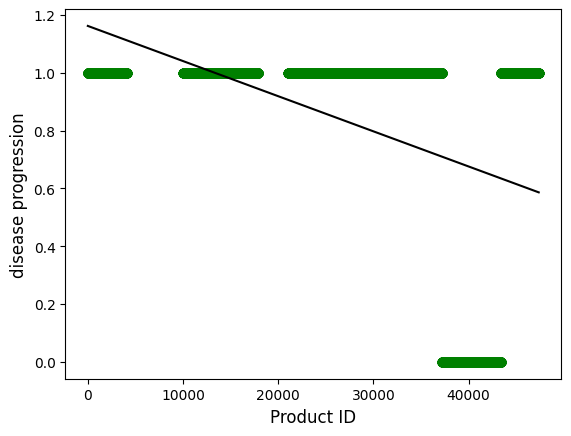

In [18]:
X2 = df['Product ID'].values[:,np.newaxis]
# target data is array of shape (n,)
y2 = df['ID_binary'].values


model2 = LinearRegression()
model2.fit(X2, y2)

plt.scatter(X2, y2,color='g')
plt.plot(X2, model2.predict(X2),color='k')
plt.ylabel('disease progression', size=12)
plt.xlabel('Product ID', size=12)
plt.show()

In [19]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=1, include_bias=False)

poly_features = poly.fit_transform(X)
X_p_train, X_p_test, y_p_train, y_p_test = train_test_split(poly_features, y, test_size=0.3, random_state=42)

In [20]:
# Create a linear regression model
modelPR = LinearRegression()

# Fit the model to the data
modelPR.fit(X_p_train, y_p_train)

# Predict the response for a new data point
y_pr_PR = modelPR.predict(X_p_test)

_ = Reg_Models_Evaluation_Metrics(modelPR, X_p_train, y_p_train, X_p_test, y_p_test, y_pr_PR)

RMSE:  0.3189
  R2: 0.2366
 Adjusted R2: 0.2364
 Cross Validated R2: 0.2344


и снова все плохо

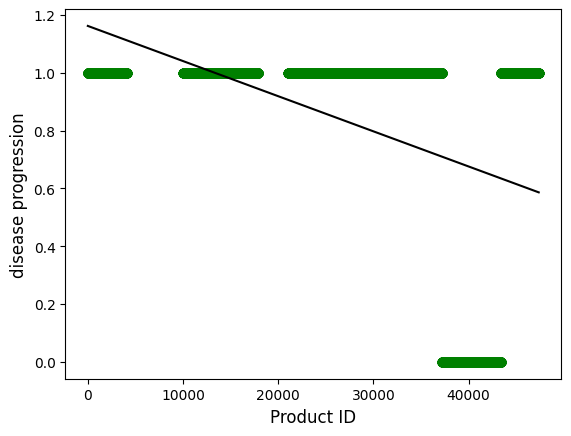

In [21]:
X2 = df['Product ID'].values[:,np.newaxis]
# target data is array of shape (n,)
y2 = df['ID_binary'].values

poly_features = poly.fit_transform(X2)

model2 = LinearRegression()
model2.fit(poly_features, y2)


plt.scatter(X2, y2,color='g')
plt.plot(X2, model2.predict(poly.fit_transform(X2)),color='k')
plt.ylabel('disease progression', size=12)
plt.xlabel('Product ID', size=12)
plt.show()

аналогичная ситуация

In [22]:
from sklearn.tree import DecisionTreeRegressor

# Create a stepwise regression model
modelDT = DecisionTreeRegressor()

# Fit the model to the data
modelDT.fit(X_train, y_train)

# Predict the response for a new data point
y_dt_pred = modelDT.predict(X_test)

In [23]:
_ = Reg_Models_Evaluation_Metrics(modelDT, X_train, y_train, X_test, y_test, y_dt_pred)

RMSE:  0.0
  R2: 1.0
 Adjusted R2: 1.0
 Cross Validated R2: 0.9996


а вот теперь интересно, предыдущие модели не могли информацию уловить, а эта переобучилась

In [24]:
from sklearn.ensemble import RandomForestRegressor

# Create a stepwise regression model
modelRF = RandomForestRegressor(n_estimators=42)

# Fit the model to the data
modelRF.fit(X_train, y_train)

# Predict the response for a new data point
y_rf_pred = modelRF.predict(X_test)


_ = Reg_Models_Evaluation_Metrics(modelRF, X_train, y_train, X_test, y_test, y_rf_pred)

RMSE:  0.0
  R2: 1.0
 Adjusted R2: 1.0
 Cross Validated R2: 0.9998


вот бы между ними было что-то среднее

In [ ]:
from sklearn.svm import SVR

# Create a support vector regression model
modelSVR = SVR(kernel='linear')

modelSVR.fit(X_train, y_train)

# Predict the response for a new data point
#y_rf_pred = modelSVR.predict(X_test)


#_ = Reg_Models_Evaluation_Metrics(modelSVR, X_train, y_train, X_test, y_test, y_rf_pred)

грузило миллион лет, так и не загрузило

должны были рисовать ее, но не можем

In [ ]:
plt.scatter(X_train["Product ID"], y_train, color='darkorange',
            label='data')
plt.plot(X_train["Product ID"], modelSVR.predict(X_train), color='cornflowerblue',
         label='prediction')
plt.legend()
plt.show()

In [ ]:
from sklearn.svm import SVR

# Create a support vector regression model. Полиномиальное ядро
modelSVR = SVR(kernel='poly')

modelSVR.fit(X_train, y_train)

# Predict the response for a new data point
#y_rf_pred = modelSVR.predict(X_test)


#_ = Reg_Models_Evaluation_Metrics(modelSVR, X_train, y_train, X_test, y_test, y_rf_pred)

че-то svr вообще не хотят работать, даже если данные уменьшить

In [ ]:
plt.scatter(X_train["Product ID"], y_train, color='darkorange',
            label='data')
plt.plot(X_train["Product ID"], modelSVR.predict(X_train), color='cornflowerblue',
         label='prediction')
plt.legend()
plt.show()

это должен был быть график к ней

In [ ]:
# Create a support vector regression model. Ядро - радиальная базисная функция
modelSVR = SVR(kernel='rbf')

modelSVR.fit(X_train, y_train)

# Predict the response for a new data point
y_rf_pred = modelSVR.predict(X_test)


_ = Reg_Models_Evaluation_Metrics(modelSVR, X_train, y_train, X_test, y_test, y_rf_pred)

все виснет на svr

In [25]:
from sklearn.linear_model import ElasticNet

# Create an elastic net regression model
modelEN = ElasticNet(alpha=0.1, l1_ratio=0.8)

# Fit the model to the data
modelEN.fit(X_train, y_train)

# Predict the response for a new data point
y_en_pred = modelEN.predict(X_test)

_ = Reg_Models_Evaluation_Metrics(modelEN, X_train, y_train, X_test, y_test, y_en_pred)

RMSE:  0.3151
  R2: 0.2404
 Adjusted R2: 0.2391
 Cross Validated R2: 0.2337


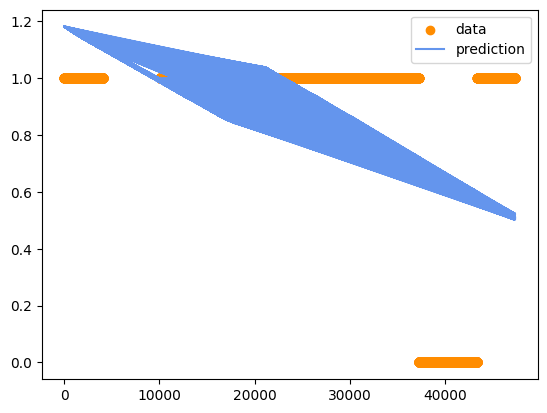

In [27]:
plt.scatter(X_train["Product ID"], y_train, color='darkorange',
            label='data')
plt.plot(X_train["Product ID"], modelEN.predict(X_train), color='cornflowerblue',
         label='prediction')
plt.legend()
plt.show()

как будто она даже что-то делит, но результаты как у первых трех

поведем итог

возможно, связь между признаками нелинейная, поэтому линейные модели ее не улавливают, а дерево же могло выучить все данные, поэтому получилось переобучение, я как раз смотрела зависимость категории от уникального айдишника, так что вполне себе мог получиться такой сценарий